In [126]:
import numpy as np
import pandas as pd
import pmdarima as pm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from statsmodels.tsa.stattools import adfuller
import plotly.express as px
import plotly.graph_objects as go
import yfinance as yf

# ARIMA Model Forecast (Baseline) 

<br>
<div class="alert alert-block alert-info"><b>
AutoRegressive Integrated Moving Average (ARIMA) is one of the most common used models in time series analysis and forecasting.
The AutoRegressive (AR) aspect is the lag of the time series that will be modeled, where we forecast future values using the previous
values, this is also done in a linear combination. 
The Integrated (I) aspect of the model is the differencing order to be used in making the time series stationary. In time series, stationarity
is where the series has a constant mean and variance - it removes the trend from a time series.
The Moving Average (MA) aspect uses past forecast errors instaed of actual values.
The ARIMA order is p - (AR),  d - (I),  q - (MA) will be seen when we fit the model later.
</b></div>
<br>

In [127]:
df = yf.Ticker('ZAR=X')
df1 = df.history(period = '12mo')[['Close']].copy()
df1 = df1.asfreq('D')
df1.head()

,Close
Date,
2025-08-28 00:00:00+01:00,17.680901
2025-08-29 00:00:00+01:00,17.680861
2025-08-30 00:00:00+01:00,NaN
2025-08-31 00:00:00+01:00,NaN
2025-09-01 00:00:00+01:00,17.638599


In [128]:
df1.isna().sum()

Close    106
dtype: int64

In [129]:
df1 = df1.ffill()
df1.isna().sum()

Close    0
dtype: int64

<br>
<div class="alert alert-block alert-info"><b>
In the cells above we import the data to be used from the yfinance library - the data will update everytime the kernel is run.
We will only use the CLose column, and do a simple check to see if there are any missing values. Setting the frequency to days 
includes non-trading days such as weekends and public holidays, therefore we forward fill the data with the previous value.
Belowe the original data is plot to see where we will be working from.
</b></div>
<br>

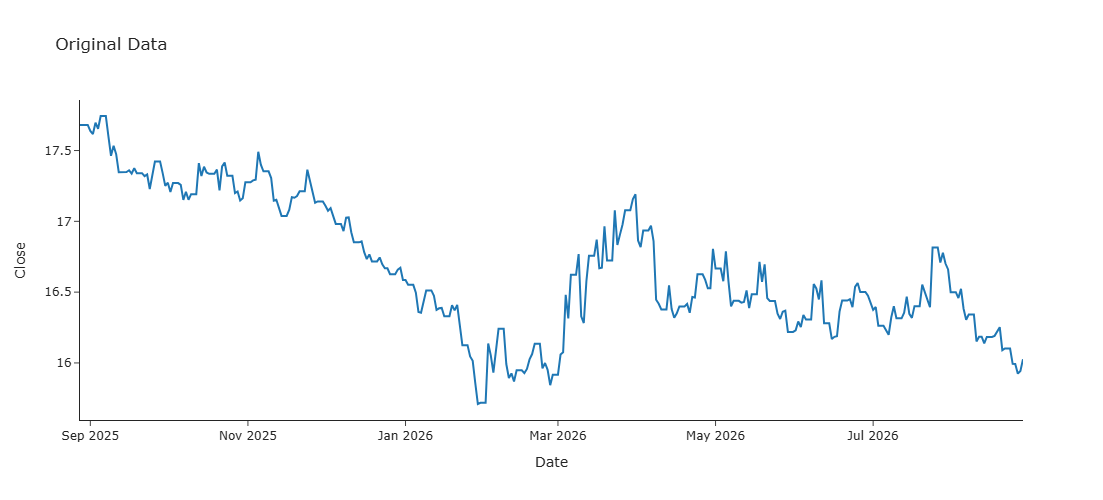

In [130]:
fig = px.line(df1, x = df1.index, y = df1['Close'],
              height = 500, width = 1000, template = 'simple_white', title = 'Original Data')
fig.show()

<br>
<div class="alert alert-block alert-info"><b>
Below we split the data into train and test sets, as well as set the forecast horizon to 30 days (Ntest). The 
train set will all the data before the final 30 days and the test set will be the final 30 days.
We also then fit the arima model using auto arima, set the max number of iterations to 10 so that the model does
not do a grid search which can take a long time to execute. We also print out the summary and the parameters, to see which
ARIMA order the model has chosen.
</b></div>
<br>

In [131]:
Ntest = 30
train = df1.iloc[:-Ntest]
test = df1.iloc[-Ntest:]

In [132]:
model = pm.auto_arima(train['Close'],
                      error_action = 'ignore', trace = True,
                      surpress_warnings = True, maxiter = 10,
                      seasonal = False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-570.098, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-566.887, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-573.340, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-574.556, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-568.619, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-573.308, Time=0.13 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-573.375, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-571.650, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-576.155, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-574.854, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-574.931, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-574.979, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-573.232, Time=0.10 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.413 seconds


In [133]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  336
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 290.078
Date:                Fri, 28 Aug 2026   AIC                           -576.155
Time:                        15:51:29   BIC                           -568.527
Sample:                    08-28-2025   HQIC                          -573.114
                         - 07-29-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1782      0.050     -3.538      0.000      -0.277      -0.079
sigma2         0.0104      0.000     22.520      0.000       0.009       0.011
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               265.46
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               2.20   Skew:                             0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [134]:
model.get_params()

{'maxiter': 10,
 'method': 'lbfgs',
 'order': (0, 1, 1),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

<br>
<div class="alert alert-block alert-info"><b>
Below we define a function that takes in the data from our model, our original data and our train and test set data. We get
the differencing order (I) from the model's parameters and use that as the starting point our train data. The test data predictions 
will be use the test set and also returns the confidence intervals for plotting.
</b></div>
<br>

In [190]:
def plot_model(model, origdata, train, test):
    params = model.get_params()
    d = params['order'][1]

    train_pred = model.predict_in_sample(start = d, end = -1)
    test_pred, confint = model.predict(n_periods = Ntest, return_conf_int = True)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x = origdata.index, y = origdata['Close'], name = 'Original Data', marker = dict(color = 'darkblue')))
    fig.add_trace(go.Scatter(x = train.index[d:], y = train_pred, name = 'Fitted Data', marker = dict(color = 'coral')))
    fig.add_trace(go.Scatter(x = test.index, y = test_pred, name = 'Forecast Data', marker = dict(color = 'lime')))
    fig.add_trace(go.Scatter(x = test.index, y = confint[:, 0], name = 'Confidence Intervals', line=dict(color='rgba(255,255,255,0)')))
    fig.add_trace(go.Scatter(x = test.index, y = confint[:, 1], 
                             fill = 'tonexty', fillcolor = 'rgba(0,100,80,0.2)', 
                             line=dict(color='rgba(255,255,255,0)'), name = 'Confidence Intervals'))
    fig.update_layout(height = 500, width = 1000, template = 'simple_white',
                     title = dict(text = 'ARIMA Model'), xaxis = dict(title = dict(text = 'Date')), yaxis = dict(title = dict(text = 'ZAR/USD Rate')))
    fig.show()

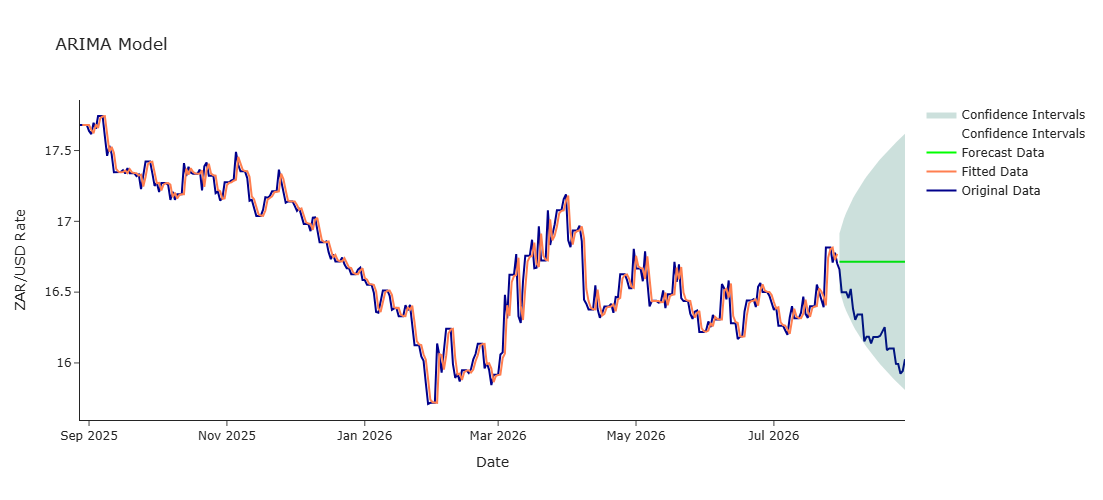

In [191]:
plot_model(model, df1, train, test)

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we can see that our model fits the training data really well, but we can see that the forecast is very far
off. The original data and the forecast are within the confidence bounds but the accuracy of the model is not good, this could
be due the train data suffering from overfitting. This is a baseline model to work from and we will explore more powerful models
to see if we can increase the predictive power/accuarcy.
</b></div>
<br>

In [137]:
def rmse(t, y):
    return np.sqrt(np.mean((t - y) ** 2))

In [138]:
print('RMSE ARIMA:', rmse(model.predict(Ntest).to_numpy(), test['Close'].to_numpy()))
print('RMSE Naive:', rmse(train['Close'].iloc[-1], test))

RMSE ARIMA: 0.5150451218085317
RMSE Naive: 0.503845712237165


In [139]:
df1['Test_Pred'] = model.predict(n_periods = Ntest, return_conf_int = False)
df1.tail(1)

,Close,Test_Pred
Date,,
2026-08-28 00:00:00+01:00,16.026501,16.714056


<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we first define a function that calculates the root mean squared error (RMSE), which is a metric that measures 
the the average difference between the predicted values produced by our model. We also use the RMSE on the naive approach which is just
the difference between the original train data and the test data. The naive approach has a slightly lower score which means that it
performs better than the ARIMA(0, 1, 1) model. In the columns we can see that the difference between the Close price and the models 
predicted price for the last current day is way off - remember that the data updates everyday.
</b></div>
<br>

# Dynamic Regression (General) Model Forecast

<br>
<div class="alert alert-block alert-info"><b>
Next we will use an ARIMAX model - this is the same as the ARIMA model but includes an Exogenous variable which could be outside factors
that could impact the price of the model. In our case we will include the Low price column. The reason for this is that in our baseline
model we could see that the forecast could not capture the actual price, the predictions were not even in the same direction.
</b></div>
<br>

In [140]:
df2 = df.history(period = '12mo')[['Close', 'Low']].copy()
df2 = df2.asfreq('D')
df2.tail()

,Close,Low
Date,,
2026-08-24 00:00:00+01:00,15.993790,15.97450
2026-08-25 00:00:00+01:00,15.992700,15.93030
2026-08-26 00:00:00+01:00,15.924240,15.89938
2026-08-27 00:00:00+01:00,15.943500,15.92820
2026-08-28 00:00:00+01:00,16.026501,15.95780


In [141]:
df2.isna().sum()

Close    106
Low      106
dtype: int64

In [142]:
df2 = df2.ffill()
df2.isna().sum()

Close    0
Low      0
dtype: int64

<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we do the same thing we did earlier. In the code cells below, we define a function to run our 
adfuller test - this is a test that helps us determine whether our data is stationary or not. We can see that our data is
not stationary. The ARIMA model will include a differencing order which helps make the data stationary - usually we would use 
the log transform of the data but because we want to predict the price of the currency not the returns, we will not make the data 
stationary.
</b></div>
<br>

In [143]:
def adf(x):
    result = adfuller(x)
    print('ADF Statistic:', result[0])
    print('P-Value:', result[1])

    if result[1] < 0.05:
        print('Stationary Series')
    else:
        print('Non-Stationary Series')

In [144]:
train2 = df2.iloc[:-Ntest].copy()
test2 = df2.iloc[-Ntest:].copy()

In [145]:
adf(train2['Close'])

ADF Statistic: -2.3326749737419648
P-Value: 0.1616460528588623
Non-Stationary Series


In [146]:
adf(train2['Low'])

ADF Statistic: -2.279958379507382
P-Value: 0.1785132813724002
Non-Stationary Series


In [147]:
dr_model = pm.auto_arima(train2['Close'],
                         X = train2[['Low']],
                         error_action = 'ignore', trace = True,
                         surpress_warnings = True, stepwise = True,
                         seasonal = False)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-948.428, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-931.407, Time=0.18 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-950.660, Time=0.24 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-947.055, Time=0.19 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-949.954, Time=0.27 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-949.462, Time=0.26 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-948.824, Time=0.45 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-948.668, Time=0.30 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 2.200 seconds


In [148]:
dr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  336
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 478.330
Date:                Fri, 28 Aug 2026   AIC                           -950.660
Time:                        15:51:32   BIC                           -939.208
Sample:                    08-28-2025   HQIC                          -946.095
                         - 07-29-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Low            1.0046      0.000   2891.334      0.000       1.004       1.005
ar.L1          0.2476      0.041      6.071      0.000       0.168       0.328
sigma2         0.0034      0.000     17.894      0.000       0.003       0.004
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):               550.15
Prob(Q):                              0.79   Prob(JB):                         0.00
Heteroskedasticity (H):               1.63   Skew:                             1.74
Prob(H) (two-sided):                  0.01   Kurtosis:                         8.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [149]:
dr_model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (1, 0, 0),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

In [188]:
def plot_dr_model(model, origdata, train, test):
    params = model.get_params()
    d = params['order'][1]

    train_pred = model.predict_in_sample(X = train[['Low']], start = d, end = -1)
    test_pred, confint = model.predict(n_periods = Ntest, X = test[['Low']], return_conf_int = True)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x = origdata.index, y = origdata['Close'], name = 'Original Data', marker = dict(color = 'darkblue')))
    fig.add_trace(go.Scatter(x = train.index[d:], y = train_pred, name = 'DR Fitted Data', marker = dict(color = 'coral')))
    fig.add_trace(go.Scatter(x = test.index, y = test_pred, name = 'DR Forecast Data', marker = dict(color = 'lime')))
    fig.add_trace(go.Scatter(x = test.index, y = confint[:, 0], name = 'Confidence Intervals', line=dict(color='rgba(255,255,255,0)')))
    fig.add_trace(go.Scatter(x = test.index, y = confint[:, 1], 
                             fill = 'tonexty', fillcolor = 'rgba(0,100,80,0.2)', 
                             line=dict(color='rgba(255,255,255,0)'), name = 'Confidence Intervals'))
    fig.update_layout(height = 500, width = 1000, template = 'simple_white',
                      title = dict(text = 'Dynamic Regression Model'), xaxis = dict(title = dict(text = 'Date')), 
                      yaxis = dict(title = dict(text = 'ZAR/USD Rate')))
    fig.show()

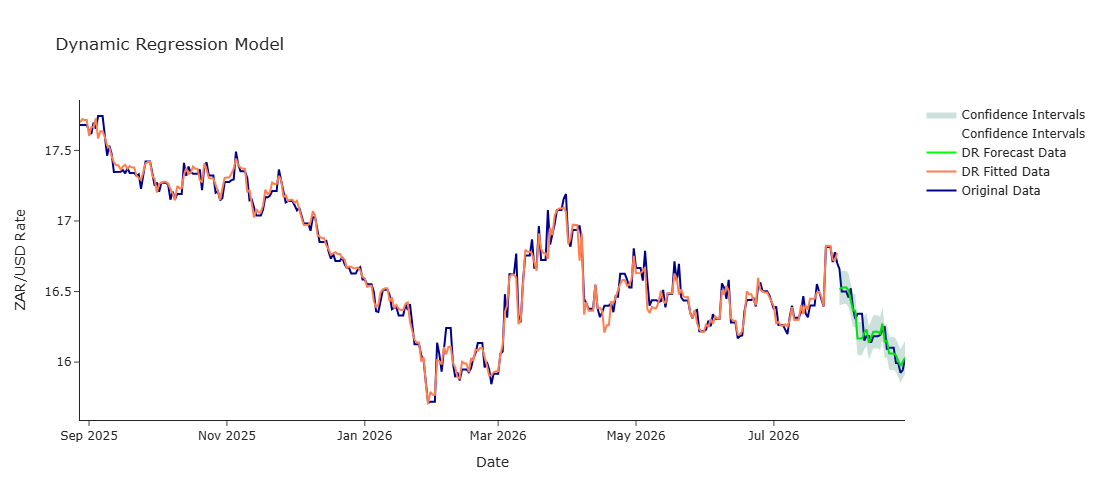

In [189]:
plot_dr_model(dr_model, df2, train2, test2)

<br>
<div class="alert alert-block alert-info"><b>
Above we fit another ARIMA model but we also use an X variable, and parse in the Low price column from our data
and plot our data as before. We use a new function because our original function cannot be used because we cannot
include our X variable in our test predictions. 

We can see that our Dynamic Regression Model does not fit the training data as well as the baseline ARIMA model - 
however - we can see that the forecast is captured really well. This shows that the model fits the training data
well but is not overfitting nor underestimating the peaks and troughs.
</b></div>
<br>

In [152]:
print('RMSE Dynamic Regression:', rmse(dr_model.predict(n_periods = Ntest, X = test2[['Low']]).to_numpy(), test2['Close'].to_numpy()))
print('RMSE Naive:', rmse(train2['Close'].iloc[-1], test2))

RMSE Dynamic Regression: 0.07555393373438699
RMSE Naive: 0.5423236729915196


In [153]:
df2['Test Pred'] = dr_model.predict(n_periods = Ntest, X = test2[['Low']], return_conf_int = False)
df2.tail(1)

,Close,Low,Test Pred
Date,,,
2026-08-28 00:00:00+01:00,16.026501,15.9578,16.030882


<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we can see that the RMSE is significantly lower than the naive approach as well as our baseline
ARIMA model. We can also see that our test prediction price and the close price are very close with the Dynamic Regression model
and that adding the Low price variable made a huge impact in our predictive accuracy as well as allowing the training data to not 
overfit the original data.
</b></div>
<br>

# Dynamic Harmonic Regression (Fourier Series) Model Forecast

<br>
<div class="alert alert-block alert-info"><b>
Next we will explore using a Harmonic Regression Model. This model uses Fourier Series as our Exogenous variables. This model
uses sine and cosine waves in the training data. This makes the model more flexible compared to just looking at past values in
a linear pattern, this model is generally used for data with a seasonal period and a cyclical pattern. We will however try to 
use it for the financial data, as it is a more powerful model.
</b></div>
<br>

In [154]:
df3 = df.history(period = '12mo')[['Close']].copy()
df3 = df3.asfreq('D')
df3.head()

,Close
Date,
2025-08-28 00:00:00+01:00,17.680901
2025-08-29 00:00:00+01:00,17.680861
2025-08-30 00:00:00+01:00,NaN
2025-08-31 00:00:00+01:00,NaN
2025-09-01 00:00:00+01:00,17.638599


In [155]:
df3 = df3.ffill()
df3.isna().sum()

Close    0
dtype: int64

In [156]:
train3 = df3.iloc[:-Ntest].copy()
test3 = df3.iloc[-Ntest:].copy()

In [157]:
train3['day_num'] = train3.index.day
test3['day_num'] = test3.index.day

<br>
<div class="alert alert-block alert-info"><b>
Below we create our Fourier Featrures to be used - in this case we are using data over a year long period that uses daily
seasonlaity. We then attach our fourier features to our training data to be used by our model.
</b></div>
<br>

In [158]:
for order in range(1, 10):
    train3[f'fourier_sin_order_{order}'] = np.sin(2 * np.pi * order * train3['day_num'] / 365.25)
    train3[f'fourier_cos_order_{order}'] = np.cos(2 * np.pi * order * train3['day_num'] / 365.25)

    test3[f'fourier_sin_order_{order}'] = np.sin(2 * np.pi * order * test3['day_num'] / 365.25)
    test3[f'fourier_cos_order_{order}'] = np.cos(2 * np.pi * order * test3['day_num'] / 365.25)

In [159]:
fourier_features = [i for i in list(train3) if i.startswith('fourier')]
train3.head()

,Close,day_num,fourier_sin_order_1,fourier_cos_order_1,fourier_sin_order_2,fourier_cos_order_2,fourier_sin_order_3,fourier_cos_order_3,fourier_sin_order_4,fourier_cos_order_4,fourier_sin_order_5,fourier_cos_order_5,fourier_sin_order_6,fourier_cos_order_6,fourier_sin_order_7,fourier_cos_order_7,fourier_sin_order_8,fourier_cos_order_8,fourier_sin_order_9,fourier_cos_order_9
Date,,,,,,,,,,,,,,,,,,,,
2025-08-28 00:00:00+01:00,17.680901,28,0.463258,0.886224,0.821100,0.570784,0.992099,0.125461,0.937342,-0.348411,0.669290,-0.743001,0.248940,-0.968519,-0.228058,-0.973648,-0.653160,-0.757220,-0.929634,-0.368484
2025-08-29 00:00:00+01:00,17.680861,29,0.478434,0.878124,0.840248,0.542202,0.997250,0.074117,0.911169,-0.412034,0.602988,-0.797750,0.147827,-0.989013,-0.343367,-0.939201,-0.750864,-0.660457,-0.975336,-0.220724
2025-08-30 00:00:00+01:00,17.680861,30,0.493468,0.869764,0.858402,0.512978,0.999745,0.022576,0.880683,-0.473706,0.532227,-0.846602,0.045141,-0.998981,-0.453703,-0.891153,-0.834370,-0.551205,-0.997707,-0.067683
2025-08-31 00:00:00+01:00,17.680861,31,0.508356,0.861147,0.875539,0.483147,0.999579,-0.029025,0.846029,-0.533137,0.457531,-0.889193,-0.058026,-0.998315,-0.557468,-0.830198,-0.902099,-0.431530,-0.996210,0.086977
2025-09-01 00:00:00+01:00,17.638599,1,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634,0.085906,0.996303,0.103031,0.994678,0.120126,0.992759,0.137185,0.990545,0.154204,0.988039


In [160]:
dhr_model = pm.auto_arima(train3['Close'],
                         X = train3[fourier_features],
                         error_action = 'ignore', trace = True,
                         surpress_warnings = True, stepwise = True,
                         seasonal = False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-535.379, Time=1.42 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-543.402, Time=0.81 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-541.419, Time=2.80 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-541.398, Time=2.56 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-545.019, Time=3.76 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-539.133, Time=2.60 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 13.973 seconds


In [161]:
dhr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  336
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 291.510
Date:                Fri, 28 Aug 2026   AIC                           -545.019
Time:                        15:51:47   BIC                           -472.551
Sample:                    08-28-2025   HQIC                          -516.128
                         - 07-29-2026                                         
Covariance Type:                  opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
fourier_sin_order_1 -1.443e+10    111.301   -1.3e+08      0.000   -1.44e+10   -1.44e+10
fourier_cos_order_1 -4.585e+10    315.407  -1.45e+08      0.000   -4.59e+10   -4.59e+10
fourier_sin_order_2 -2.899e+10    516.468  -5.61e+07      0.000    -2.9e+10    -2.9e+10
fourier_cos_order_2 -4.768e+10    858.847  -5.55e+07      0.000   -4.77e+10   -4.77e+10
fourier_sin_order_3  3.807e+10    950.123   4.01e+07      0.000    3.81e+10    3.81e+10
fourier_cos_order_3  3.348e+10    905.606    3.7e+07      0.000    3.35e+10    3.35e+10
fourier_sin_order_4  3.064e+10    637.026   4.81e+07      0.000    3.06e+10    3.06e+10
fourier_cos_order_4   1.59e+10    337.328   4.71e+07      0.000    1.59e+10    1.59e+10
fourier_sin_order_5 -8.174e+10    566.535  -1.44e+08      0.000   -8.17e+10   -8.17e+10
fourier_cos_order_5 -1.466e+10    168.196  -8.72e+07      0.000   -1.47e+10   -1.47e+10
fourier_sin_order_6  6.361e+10   1446.552    4.4e+07      0.000    6.36e+10    6.36e+10
fourier_cos_order_6 -6.872e+09    118.590  -5.79e+07      0.000   -6.87e+09   -6.87e+09
fourier_sin_order_7 -2.453e+10    462.929   -5.3e+07      0.000   -2.45e+10   -2.45e+10
fourier_cos_order_7   1.01e+10    160.443    6.3e+07      0.000    1.01e+10    1.01e+10
fourier_sin_order_8  4.678e+09   1532.904   3.05e+06      0.000    4.68e+09    4.68e+09
fourier_cos_order_8 -3.727e+09   1032.921  -3.61e+06      0.000   -3.73e+09   -3.73e+09
fourier_sin_order_9 -3.358e+08    447.152  -7.51e+05      0.000   -3.36e+08   -3.36e+08
fourier_cos_order_9  4.738e+08    516.002   9.18e+05      0.000    4.74e+08    4.74e+08
sigma2                  0.0104      0.001     18.639      0.000       0.009       0.011
===================================================================================
Ljung-Box (L1) (Q):                   9.91   Jarque-Bera (JB):               196.04
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.23   Skew:                             0.38
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.81e+19. Standard errors may be unstable.
"""

In [162]:
dhr_model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (0, 1, 0),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

In [192]:
def plot_dhr_model(model, origdata, train, test):
    params = model.get_params()
    d = params['order'][1]

    train_pred = model.predict_in_sample(X = train[fourier_features], start = d, end = -1)
    test_pred, confint = model.predict(n_periods = Ntest, X = test[fourier_features], return_conf_int = True)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x = origdata.index, y = origdata['Close'], name = 'Original Data', marker = dict(color = 'darkblue')))
    fig.add_trace(go.Scatter(x = train.index[d:], y = train_pred, name = 'DHR Fitted Data', marker = dict(color = 'coral')))
    fig.add_trace(go.Scatter(x = test.index, y = test_pred, name = 'DHR Forecast Data', marker = dict(color = 'lime')))
    fig.add_trace(go.Scatter(x = test.index, y = confint[:, 0], name = 'Confidence Intervals', line=dict(color='rgba(255,255,255,0)')))
    fig.add_trace(go.Scatter(x = test.index, y = confint[:, 1], 
                             fill = 'tonexty', fillcolor = 'rgba(0,100,80,0.2)', 
                             line=dict(color='rgba(255,255,255,0)'), name = 'Confidence Intervals'))
    fig.update_layout(height = 500, width = 1000, template = 'simple_white',
                      title = dict(text = 'Dynamic Harmonic Regression Model'), xaxis = dict(title = dict(text = 'Date')), 
                      yaxis = dict(title = dict(text = 'ZAR/USD Rate')))
    fig.show()

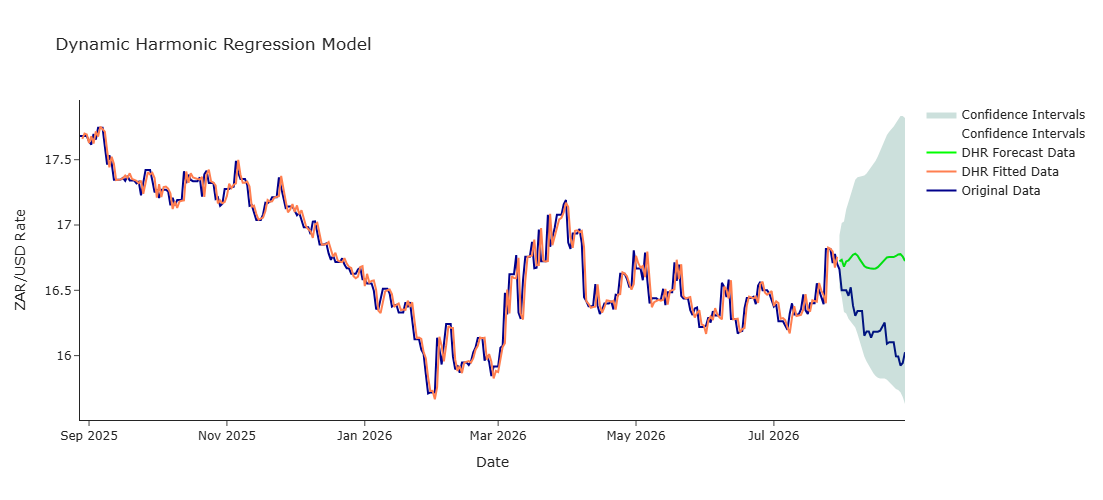

In [193]:
plot_dhr_model(dhr_model, df3, train3, test3)

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we can see that our model fits the data quite well but similar to the baseline ARIMA model, it
cannot forecast as well as a genral dynamic regression model. In the training data we can see in some points that
the model actually estimates beyond the actual price, specifically in the lower points (troughs). With Harmonic Regression Models
it is assumed that the seasonality is fixed throughout and that could be why the model is underperforming - the volatility of
currency prices cannot be captured by models with fixed seasonality attributes.
</b></div>
<br>

In [196]:
print('RMSE Dynamic Harmonic Regression:', rmse(dhr_model.predict(n_periods = Ntest, 
                                           X = test3[fourier_features]).to_numpy(), test3['Close'].to_numpy()))
print('RMSE Naive:', rmse(train3['Close'].iloc[-1], test3['Close']))

RMSE Dynamic Harmonic Regression: 0.528963282953275
RMSE Naive: 0.503845712237165


In [166]:
df3['Test Pred'] = dhr_model.predict(n_periods = Ntest, X = test3[fourier_features], return_conf_int = False)
df3.tail(1)

,Close,Test Pred
Date,,
2026-08-28 00:00:00+01:00,16.026501,16.724083


<br>
<div class="alert alert-block alert-info"><b>
We cam see that our RMSE is worse than the naive approach and actually even worse that the baseline ARIMA model.
The test prediction is also further off compared to our other models, can see that this model would not work
well with the volatile nature of financial markets.
</b></div>
<br>

# Linear Regression (Machine Learning) Model Forecast

<br>
<div class="alert alert-block alert-info"><b>
Lastly, we use a machine learning approach for forecasting. We use a Linear Regression Model to forecast our data. This approach
is not traditional compared to more established time series models and will require a few adjustments, however, machine learning
models are quite powerful and are starting to be used in time series analysis more often.
</b></div>
<br>

In [167]:
df4 = df.history(period = '12mo')[['Close']].copy()
df4.head()

,Close
Date,
2025-08-28 00:00:00+01:00,17.680901
2025-08-29 00:00:00+01:00,17.680861
2025-09-01 00:00:00+01:00,17.638599
2025-09-02 00:00:00+01:00,17.616240
2025-09-03 00:00:00+01:00,17.696400


In [168]:
df4.isna().sum()

Close    0
dtype: int64

In [169]:
train4 = df4.iloc[:-Ntest].copy()
test4 = df4.iloc[-Ntest:].copy()

<br>
<div class="alert alert-block alert-info"><b>
Linear Regression models and packages like Scikit-Learn are not traditionally used for time series analysis, we therefore have
to make some changes to structure or shape our data in a way that lends itself to time series forecasting techniques. The code
cells above load and check the data same as with previous models. The cell below reshapes our data. First by converting data to a
numpy array for easier indexing, set X and Y variables as empty arrays - these variables will be our inputs (X) and targets (Y), variable
T set to 10 will represent the lags in the model. The lags are the past values that will be used as input features for the forecasting model.
Inside the loop we basically select the train data (X) and the test data (Y) and then append these to our empty arrays and convert them to
numpy arrays. 
</b></div>    
</b>

In [201]:
series = df4['Close'].to_numpy()

T = 10
X = []
Y = []

for t in range(len(series) - T):
    x = series[t: t + T]
    X.append(x)

    y = series[t + T]
    Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)

print('X_shape:', X.shape, 'Y_shape:', Y.shape)

X_shape: (250, 10) Y_shape: (250,)


<br>
<div class="alert alert-block alert-info"><b>
In the next 2 code cells we instantiate and fit our Linear Regression Model to newly structured data and get the r2 score for
both the train and test data. The train data has a score over 90% and the test data about 80%, so our model does seem to fit the
data fairly well and we could expect to see a model that can capture the trend of the data and produce a decent forecast.
</b></div>
</br>

In [171]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

lr = LinearRegression()
lr.fit(Xtrain, Ytrain)

LinearRegression()

In [172]:
lr.score(Xtrain, Ytrain), lr.score(Xtest, Ytest)

(0.9342802089697424, 0.7956004690015829)

<br>
<div class="alert alert-block alert-info"><b>
The next 2 code cells are used create a train and test index, so that all our data can be used on the same axis with
the same index values. We then also call the predict function on our train and test sets. The test_std variable created is
created to calculate the standard deviation of the test data and will be used to create confidence intervals in the plot
because Scikit-Learn does not have confidence intervals like the ARIMA packages.
</b></div>
</br>

In [173]:
train4_idx = df4.index <= train4.index[-1]
test4_idx = ~train4_idx
train4_idx[:T] = False

df4.loc[train4_idx, 'LR_Train'] = lr.predict(Xtrain)
df4.loc[test4_idx, 'LR_Test'] = lr.predict(Xtest)

In [174]:
test_std = df4['LR_Test'].std()
test_std

0.23143173986157908

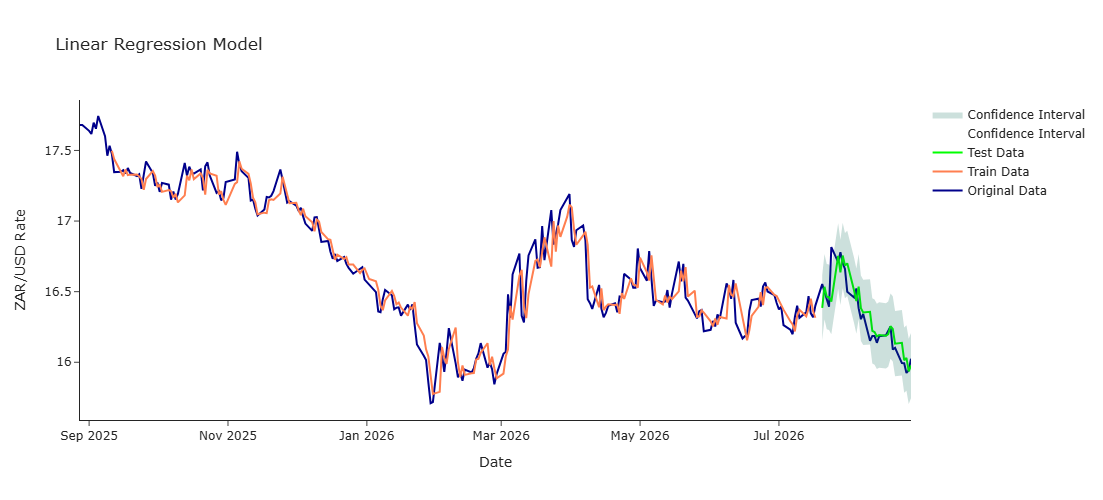

In [194]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = df4.index, y = df4['Close'], name = 'Original Data', marker = dict(color = 'darkblue')))
fig.add_trace(go.Scatter(x = df4.index, y = df4['LR_Train'], name = 'Train Data', marker = dict(color = 'coral')))
fig.add_trace(go.Scatter(x = df4.index, y = df4['LR_Test'], name = 'Test Data', marker = dict(color = 'lime')))
fig.add_trace(go.Scatter(
        name='Confidence Interval',
        x=df4.index,
        y=df4['LR_Test']+test_std,
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=True
    ))
fig.add_trace(go.Scatter(
        name='Confidence Interval',
        x=df4.index,
        y=df4['LR_Test']-test_std,
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(0,100,80,0.2)', 
        fill='tonexty',
        showlegend=True
    ))
fig.update_layout(height = 500, width = 1000, template = 'simple_white',
                  title = dict(text = 'Linear Regression Model'), xaxis = dict(title = dict(text = 'Date')), 
                  yaxis = dict(title = dict(text = 'ZAR/USD Rate')))
fig.show()

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we can see that the model captures the trend of the data quite well - without overfitting and we can see that
the first 10 values are not captured, which is due to the lagged values we used. The forecast seems to be quite good as well and
looks to be nearly as good as the General Dynamic Regression Model.

We include the Mean Absolute Percentage Error (MAPE) for the Linear Regression as well (used with machine learning models), and we
can see that the RMSE is lower than the ARIMA baseline and the Harmonic Regression models. Our price predictions are also much closer
to the actual price
</b></div>
</br>

In [211]:
mape = mean_absolute_percentage_error(Ytest, df4.loc[test4_idx, 'LR_Test'])
print('Linear Regression MAPE:', mape)

print('RMSE Linear Regression:', rmse(lr.predict(Xtest), Ytest))
print('RMSE Naive:', rmse(train4['Close'].iloc[-1], Ytest))

Linear Regression MAPE: 0.004809463575667871
RMSE Linear Regression: 0.11451327097363219
RMSE Naive: 0.26532039366771076


In [178]:
df4[['Close', 'LR_Test']].tail(1)

,Close,LR_Test
Date,,
2026-08-28 00:00:00+01:00,16.025631,15.976267
